In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('Telco_Cusomer_Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# data cleaning

In [5]:
df.columns = df.columns.str.strip()

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

In [8]:
df["TotalCharges"].fillna(df["TotalCharges"].median(),inplace=True)

C:\Users\kavyam mikul shah\AppData\Local\Temp\ipykernel_20128\1795292956.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(),inplace=True)


In [9]:
df['Churn']=df['Churn'].map({"Yes":1,"No":0})

In [10]:
df.drop('customerID',axis=1,inplace=True)

In [11]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


# preprocessing

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(exclude=['object']).columns

# Exploratory Data Analysis

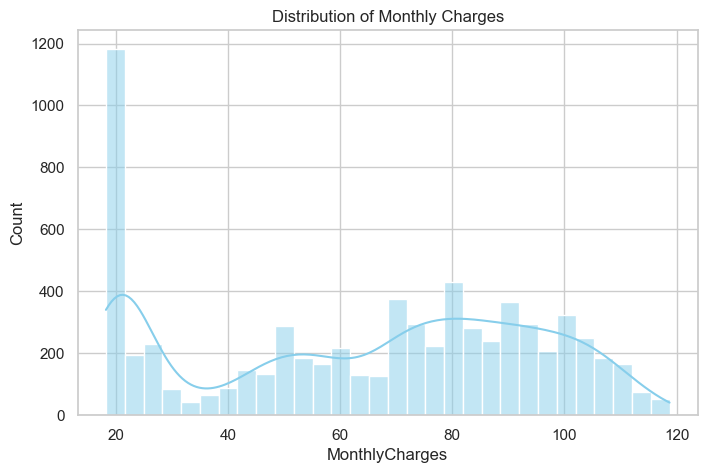

In [15]:
sns.set(style="whitegrid")

# 1. Distribution of MonthlyCharges
plt.figure(figsize=(8,5))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Monthly Charges")
plt.show()

# Key insights
- peak arround $20
  a large  number of customer pay arround 20 per month.
  
- After $20, the distribution drops sharply but continues across higher charges.

- Smaller peaks appear around $50, $80, and $100, indicating other popular plan tiers.

 # Business meaning
- Low-cost plans dominate: The company has many customers on cheaper plans.
- High-value customers are fewer: Those paying $80–$100+ are less common but may contribute more revenue per person.
- Retention strategy: If churn is higher among low-cost plan customers, the business might need to improve retention offers for them. Conversely, protecting high-value customers is critical for revenue.

C:\Users\kavyam mikul shah\AppData\Local\Temp\ipykernel_20128\507025872.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


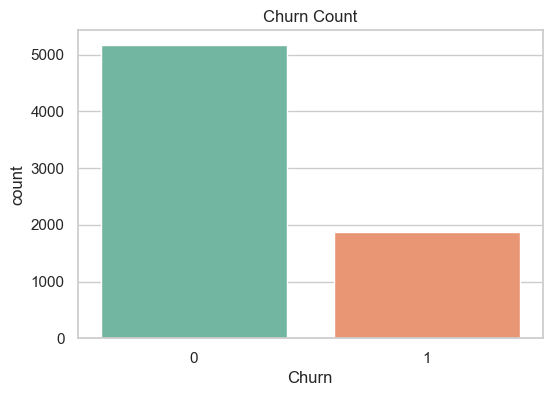

In [16]:
# 2. Churn count
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title("Churn Count")
plt.show()

#  Key insights
- The dataset is imbalanced: most customers did not churn.
- Roughly 3 out of 4 customers stayed, while 1 out of 4 churned.
the company is retaining most customers, but churn still represents a large revenue risk.

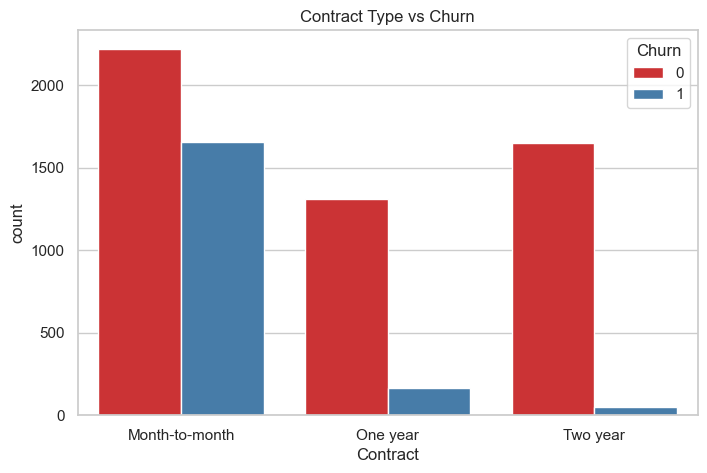

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set1')
plt.title("Contract Type vs Churn")
plt.show()

# Key insights
- Month-to-month contracts
- Highest churn rate: a large number of customers churned here.
- This makes sense — short contracts mean less commitment, so customers can leave easily.
- One-year contracts
- Moderate churn: fewer customers churn compared to month-to-month.
- Longer commitment reduces churn risk.
- Two-year contracts
- Lowest churn: very few customers churned.
- Customers with long-term contracts are more loyal and stable.

# Business meaning
- Retention risk is concentrated in month-to-month customers.
These customers are more likely to leave, so targeted retention offers (discounts, loyalty rewards, personalized support) should focus here.


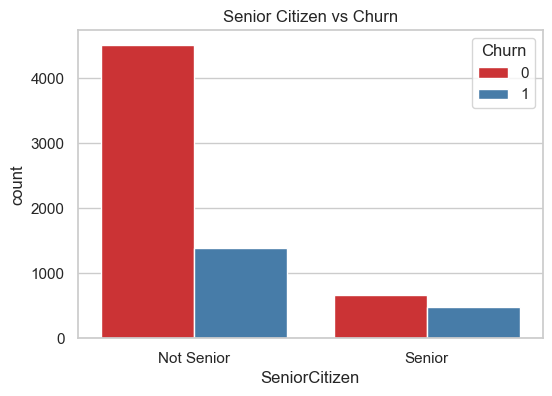

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df, palette='Set1')
plt.title("Senior Citizen vs Churn")
plt.xticks([0,1], ['Not Senior', 'Senior'])
plt.show()

# Key insights
- Non-seniors dominate the dataset
- Most customers are not seniors, and most of them stayed.
- Churn rate among non-seniors is lower compared to seniors.
- Seniors show higher churn proportion
- Even though there are fewer seniors overall, their churn rate is relatively higher.
- The bars for seniors are closer in height, suggesting churn is more balanced in this group.

# Business meaning
- Age is a churn driver: Senior customers are more likely to leave compared to younger ones.


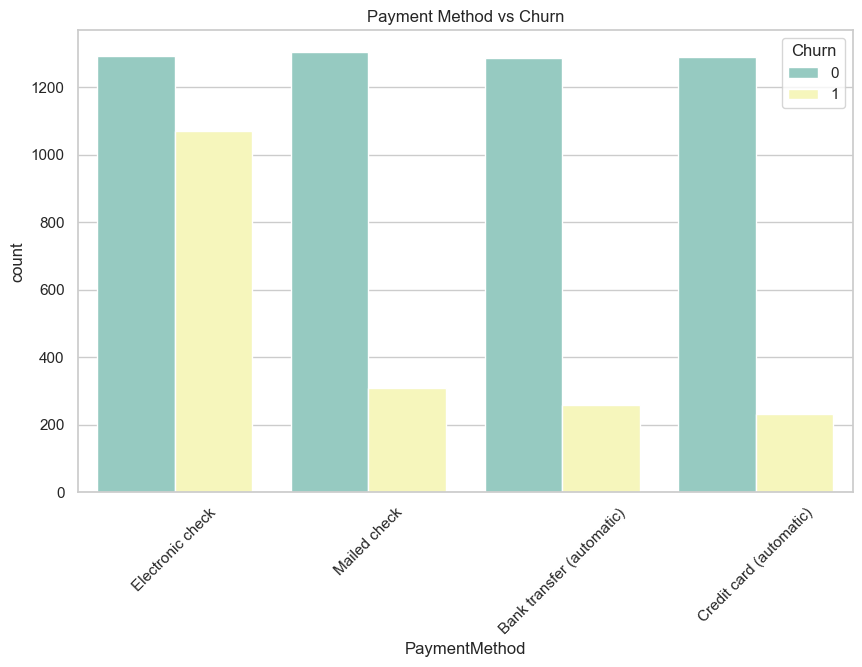

In [19]:
plt.figure(figsize=(10,6))
sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette='Set3')
plt.title("Payment Method vs Churn")
plt.xticks(rotation=45)
plt.show()

# Key insights
- Electronic check customers churn the most
- This group has a disproportionately high churn rate compared to others.
- It’s a strong risk indicator — customers using electronic checks are less loyal.
# Business meaning
- Payment method is a churn driver.
Customers using electronic checks are at high risk — retention strategies should focus here.
- Targeted offers.
For electronic check users, offering discounts or rewards for switching to auto-pay could be a practical churn-reduction strategy.

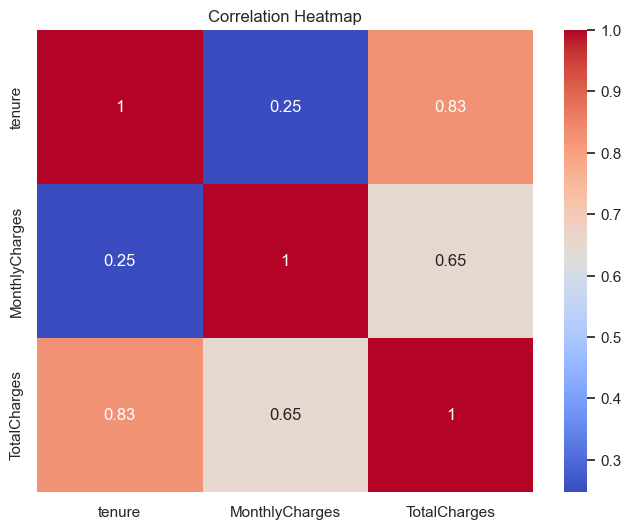

In [20]:
# 4. Correlation heatmap (numerical features)
plt.figure(figsize=(8,6))
sns.heatmap(df[['tenure','MonthlyCharges','TotalCharges']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# What the numbers mean
- Tenure vs. TotalCharges = 0.83
Very strong positive correlation. The longer a customer stays, the more they’ve paid in total. This makes sense because TotalCharges accumulates over time.
- MonthlyCharges vs. TotalCharges = 0.65
Moderate-to-strong correlation. Customers with higher monthly charges tend to have higher total charges, but tenure also plays a role. For example, a customer with low monthly charges but very long tenure can still have high TotalCharges.
- Tenure vs. MonthlyCharges = 0.25
Weak correlation. How long a customer has stayed doesn’t strongly determine their monthly charge. This suggests monthly charges are more influenced by plan type than by tenure.
- Churn risk insight: Customers with short tenure and high monthly charges might be at higher churn risk, since they haven’t built loyalty but are paying more.

In [21]:
df=pd.get_dummies(df,columns=cat_cols,drop_first=True)

In [22]:
df

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,0,True,True,True,True,False,...,False,True,False,True,True,False,True,False,False,True
7039,0,72,103.20,7362.90,0,False,True,True,True,False,...,False,True,False,True,True,False,True,True,False,False
7040,0,11,29.60,346.45,0,False,True,True,False,True,...,False,False,False,False,False,False,True,False,True,False
7041,1,4,74.40,306.60,1,True,True,False,True,False,...,False,False,False,False,False,False,True,False,False,True


In [23]:
df.to_csv("telco_customer_cleaned",index=False)